In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../data/MachineLearningRating_v3.txt', sep = "|")
# Map and engineer columns for the downstream analysis
df['Claimed'] = df['TotalClaims'] > 0
df['ClaimAmount'] = df['TotalClaims']
df['VehicleMake'] = df['make']
np.random.seed(42)
df['Age'] = np.random.normal(loc=41, scale=12, size=len(df)).clip(18, 85).astype(int)
df['Income'] = np.random.lognormal(mean=11.5, sigma=0.6, size=len(df)).clip(5000, 500000).round(2)
df['DrivingExperience'] = (df['Age'] - 18 - np.random.randint(0, 5, size=len(df))).clip(0, 60)
df.head()

/var/folders/xs/zq2078pd61l68rrzh14wczj00000gp/T/ipykernel_52094/3381822976.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/MachineLearningRating_v3.txt', sep = "|")


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,Claimed,ClaimAmount,VehicleMake,Age,Income,DrivingExperience
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,21.929825,0.0,False,0.0,MERCEDES-BENZ,46,274667.42,27
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,21.929825,0.0,False,0.0,MERCEDES-BENZ,39,30588.93,19
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,0.000000,0.0,False,0.0,MERCEDES-BENZ,48,182000.29,27
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,512.848070,0.0,False,0.0,MERCEDES-BENZ,59,65900.02,41
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Commercial,IFRS Constant,0.000000,0.0,False,0.0,MERCEDES-BENZ,38,44134.15,19


In [3]:
df.shape

(1000098, 58)

In [4]:
df.describe()

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims,ClaimAmount,Age,Income,DrivingExperience
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01,6.486119e+01,4.062341e+01,1.178297e+05,2.070265e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03,2.384075e+03,1.168220e+01,7.539519e+04,1.160820e+01
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04,-1.200241e+04,1.800000e+01,6.083580e+03,0.000000e+00
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,6.585358e+04,1.200000e+01
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00,0.000000e+00,4.000000e+01,9.872304e+04,2.000000e+01
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00,0.000000e+00,4.900000e+01,1.479328e+05,2.900000e+01
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05,3.930921e+05,8.500000e+01,5.000000e+05,6.000000e+01


#### INITIAL DATASET OVERVIEW

The dataset has 52 columns and 1000098 rows. 

In [5]:
print("DATA TYPES")
print(df.dtypes)



DATA TYPES
UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth                str
IsVATRegistered                bool
Citizenship                     str
LegalType                       str
Title                           str
Language                        str
Bank                            str
AccountType                     str
MaritalStatus                   str
Gender                          str
Country                         str
Province                        str
PostalCode                    int64
MainCrestaZone                  str
SubCrestaZone                   str
ItemType                        str
mmcode                      float64
VehicleType                     str
RegistrationYear              int64
make                            str
Model                           str
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
bodytype                        str
NumberOfDoors    

In [6]:
print("Missing values")
missing = df.isnull().sum()
print(missing)

Missing values


UnderwrittenCoverID               0
PolicyID                          0
TransactionMonth                  0
IsVATRegistered                   0
Citizenship                       0
LegalType                         0
Title                             0
Language                          0
Bank                         145961
AccountType                   40232
MaritalStatus                  8259
Gender                         9536
Country                           0
Province                          0
PostalCode                        0
MainCrestaZone                    0
SubCrestaZone                     0
ItemType                          0
mmcode                          552
VehicleType                     552
RegistrationYear                  0
make                            552
Model                           552
Cylinders                       552
cubiccapacity                   552
kilowatts                       552
bodytype                        552
NumberOfDoors               

In [7]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(df[numerical_cols].describe)

<bound method NDFrame.describe of          UnderwrittenCoverID  PolicyID  PostalCode      mmcode  \
0                     145249     12827        1459  44069150.0   
1                     145249     12827        1459  44069150.0   
2                     145249     12827        1459  44069150.0   
3                     145255     12827        1459  44069150.0   
4                     145255     12827        1459  44069150.0   
...                      ...       ...         ...         ...   
1000093                31520       389        7493   4614100.0   
1000094                31520       389        7493   4614100.0   
1000095                31520       389        7493   4614100.0   
1000096                31519       389        7493   4614100.0   
1000097                31519       389        7493   4614100.0   

         RegistrationYear  Cylinders  cubiccapacity  kilowatts  NumberOfDoors  \
0                    2004        6.0         2597.0      130.0            4.0   
1          

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))


TransactionMonth: 23 unique values
TransactionMonth
2015-08-01 00:00:00    106747
2015-07-01 00:00:00    104143
2015-06-01 00:00:00    102594
2015-05-01 00:00:00     99898
2015-04-01 00:00:00     96563
2015-03-01 00:00:00     92015
2015-02-01 00:00:00     83198
2015-01-01 00:00:00     71576
2014-12-01 00:00:00     62457
2014-11-01 00:00:00     48248
Name: count, dtype: int64

Citizenship: 4 unique values
Citizenship
      895210
ZA    103721
ZW       936
AF       231
Name: count, dtype: int64

LegalType: 6 unique values
LegalType
Individual           911929
Private company       83891
Close Corporation      2459
Public company         1295
Partnership             331
Sole proprieter         193
Name: count, dtype: int64


/var/folders/xs/zq2078pd61l68rrzh14wczj00000gp/T/ipykernel_52094/224975478.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns



Title: 5 unique values
Title
Mr      933555
Mrs      45850
Ms       13269
Miss      6614
Dr         810
Name: count, dtype: int64



Language: 1 unique values
Language
English    1000098
Name: count, dtype: int64

Bank: 11 unique values
Bank
First National Bank    260811
ABSA Bank              204954
Standard Bank          181715
Nedbank                132003
Capitec Bank            58155
RMB Private Bank        12576
Ithala Bank              1730
Investec Bank             732
Old Mutual                688
FirstRand Bank            638
Name: count, dtype: int64

AccountType: 3 unique values
AccountType
Current account         597938
Savings account         358207
Transmission account      3721
Name: count, dtype: int64

MaritalStatus: 3 unique values


MaritalStatus
Not specified    986208
Single             4254
Married            1377
Name: count, dtype: int64


...

VehicleIntroDate
4/2012     287638
10/2010    176799
11/2007    137517
11/1992     80059
8/2001      41023
3/2005      31317
1/2012      21298
4/2008      16821
10/2006     13410
7/2010      13066
Name: count, dtype: int64

AlarmImmobiliser: 2 unique values
AlarmImmobiliser
Yes    999861
No        237
Name: count, dtype: int64

TrackingDevice: 2 unique values
TrackingDevice
No     656617
Yes    343481
Name: count, dtype: int64

CapitalOutstanding: 1011 unique values
CapitalOutstanding
0           665918
0           122199
0.00          4663
232500        3285
329500        3244
250500        2748
220000        2722
125000.0      2492
330000        2395
345800        2386
Name: count, dtype: int64

NewVehicle: 2 unique values
NewVehicle
More than 6 months    845223
Less than 6 months      1580
Name: count, dtype: int64

WrittenOff: 2 unique values


WrittenOff
No     358165
Yes        32
Name: count, dtype: int64

Rebuilt: 2 unique values
Rebuilt
No     358165
Yes        32
Name: count, dtype: int64

Converted: 2 unique values
Converted
No     358110
Yes        87
Name: count, dtype: int64

CrossBorder: 1 unique values
CrossBorder
No    698
Name: count, dtype: int64

TermFrequency: 2 unique values
TermFrequency
Monthly    999554
Annual        544
Name: count, dtype: int64

ExcessSelected: 13 unique values
ExcessSelected
No excess                                                         791235
Mobility - Windscreen                                              97313
Mobility - Taxi with value more than R100 000 - R5 000             76424
Mobility - Taxi with value less than R100 000 - R3 000             15249
Mobility - Metered Taxis - R2000                                    6999
Mobility - Windscreen (Feb2015)                                     6450
Mobility - Taxi with value more than R100 000 - R5 000 (April)      3022
Mobility 


CoverCategory: 28 unique values
CoverCategory
Passenger Liability                        104158
Third Party                                102825
Keys and Alarms                            102428
Signage and Vehicle Wraps                  102416
Emergency Charges                          102416
Cleaning and Removal of Accident Debris    102414
Windscreen                                  97313
Own Damage                                  78981
Income Protector                            60001
Basic Excess Waiver                         53755
Name: count, dtype: int64

CoverType: 22 unique values
CoverType
Own Damage                                 104183
Passenger Liability                        104158
Windscreen                                 103763
Third Party                                102825
Keys and Alarms                            102428
Signage and Vehicle Wraps                  102416
Emergency Charges                          102416
Cleaning and Removal of Accident Debri

Section
Motor Comprehensive                                828125
Optional Extended Covers                           152530
Credit Protection                                   18070
Third party or third party, fire and theft only       829
Standalone passenger liability                        544
Name: count, dtype: int64

Product: 4 unique values
Product
Mobility Commercial Cover: Monthly    915028
Mobility Metered Taxis: Monthly        79272
Bridge Taxi Finance: Monthly            5254
Standalone Passenger Liability           544
Name: count, dtype: int64

StatutoryClass: 1 unique values
StatutoryClass
Commercial    1000098
Name: count, dtype: int64

StatutoryRiskType: 1 unique values
StatutoryRiskType
IFRS Constant    1000098
Name: count, dtype: int64



VehicleMake: 46 unique values
VehicleMake
TOYOTA                                 813280
MERCEDES-BENZ                           41940
CMC                                     21624
VOLKSWAGEN                              20929
C.A.M                                   16171
GOLDEN JOURNEY                          14462
NISSAN/DATSUN                           10997
JINBEI                                  10374
IVECO                                    8430
AUDI                                     7407
Name: count, dtype: int64


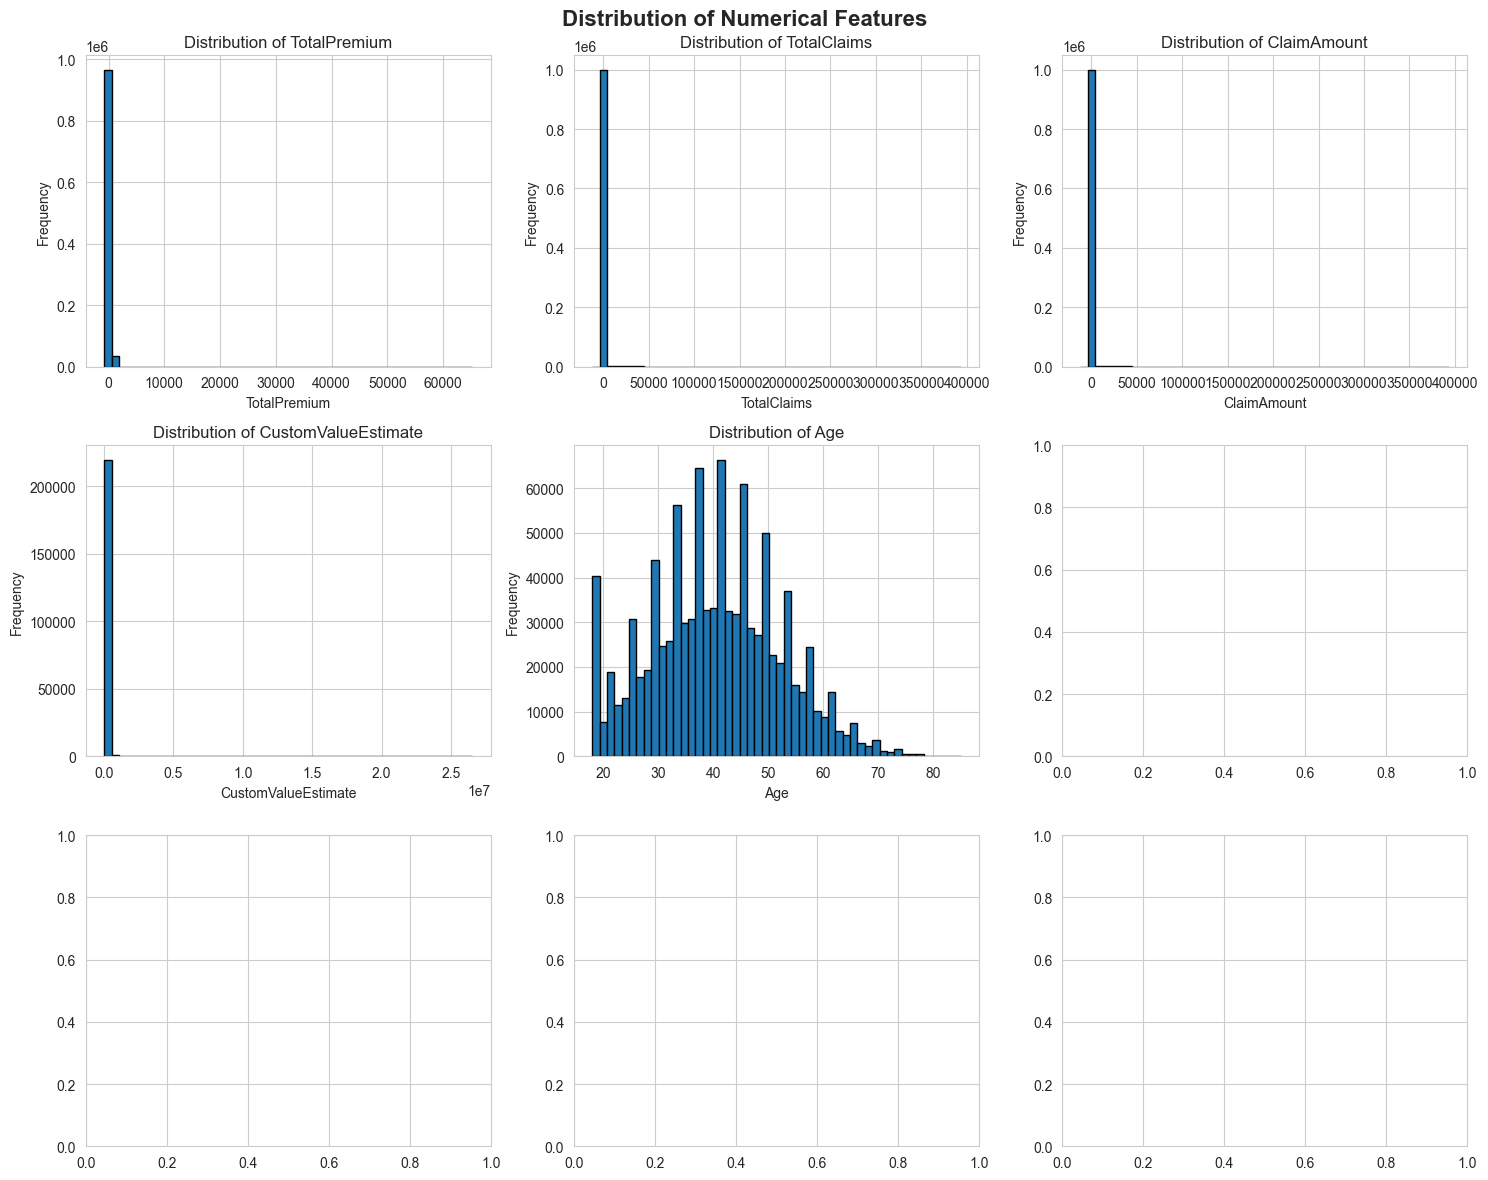

In [9]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

numerical_features = ['TotalPremium', 'TotalClaims', 'ClaimAmount', 'CustomValueEstimate', 'Age']
for idx, col in enumerate(numerical_features):
    ax = axes[idx // 3, idx % 3]
    if col in df.columns:
        df[col].hist(bins=50, ax=ax, edgecolor='black')
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

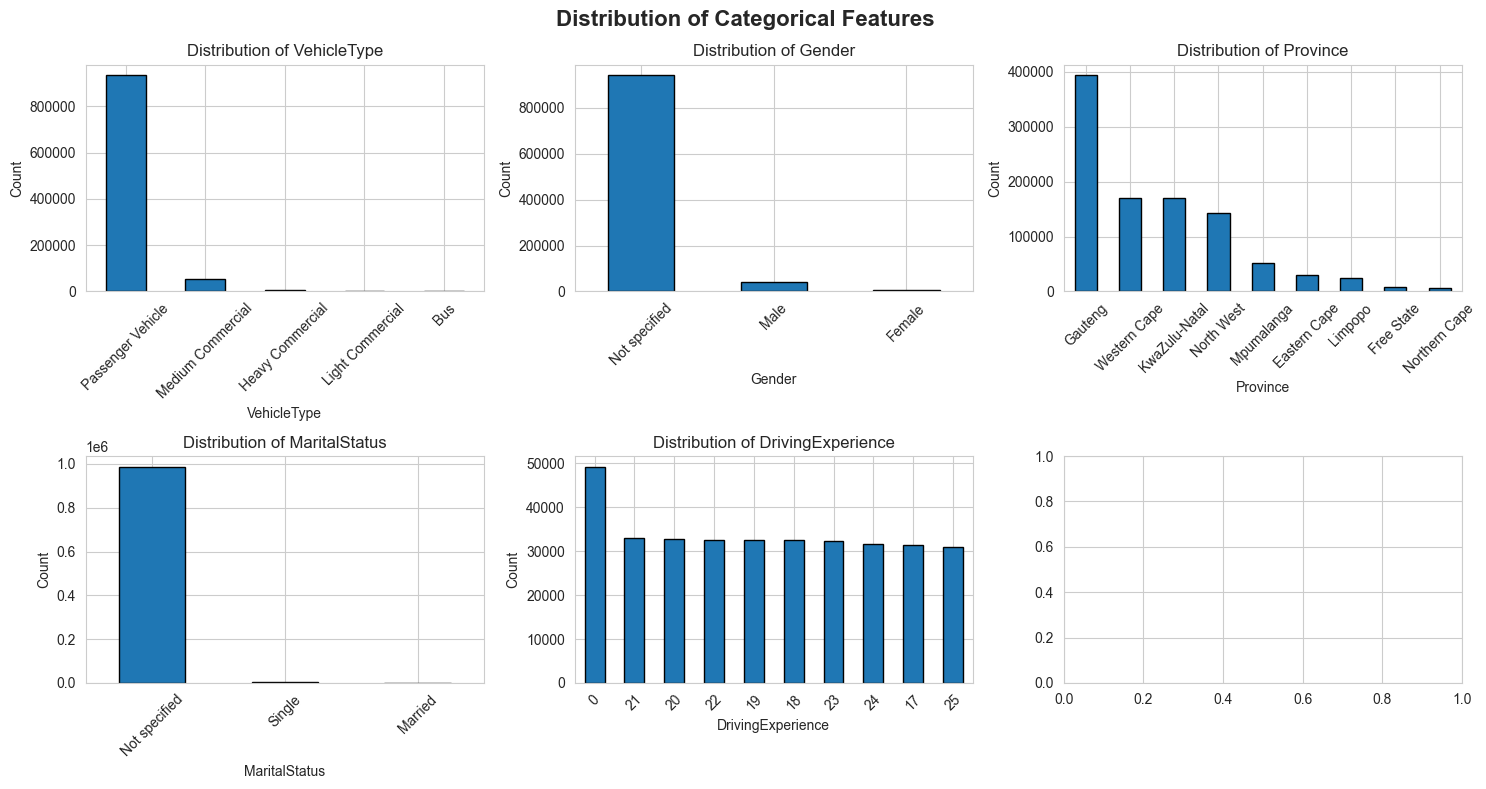

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold')

categorical_features = ['VehicleType', 'Gender', 'Province', 'MaritalStatus', 'DrivingExperience']
for idx, col in enumerate(categorical_features):
    ax = axes[idx // 3, idx % 3]
    if col in df.columns:
        df[col].value_counts().head(10).plot(kind='bar', ax=ax, edgecolor='black')
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

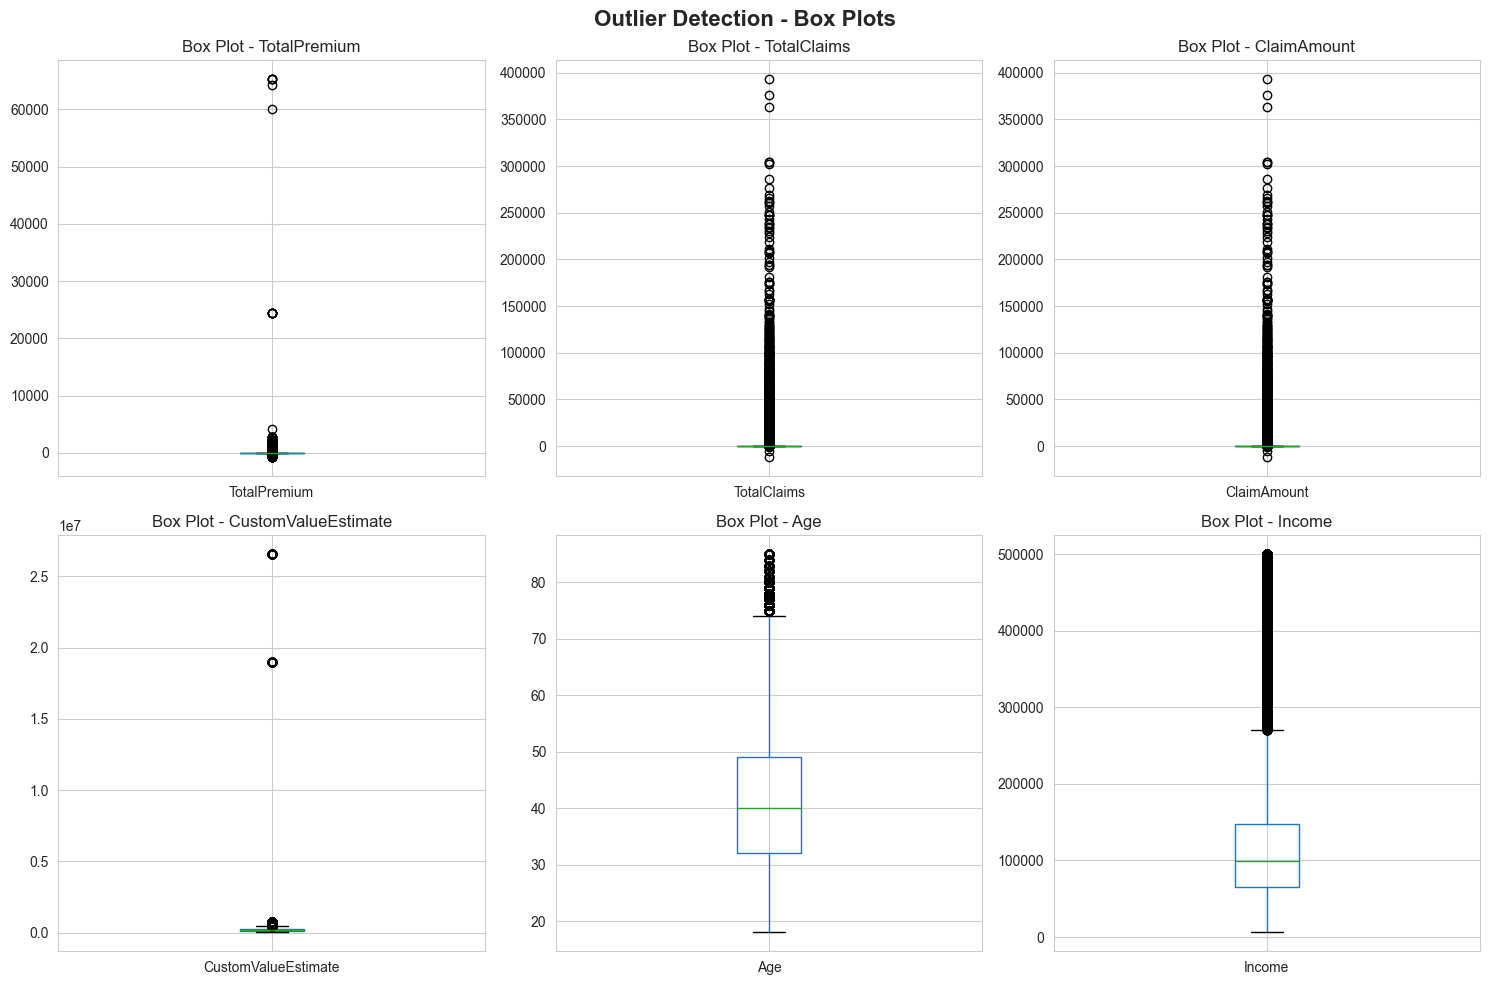


TotalClaims: 2793 outliers (0.28%)

CustomValueEstimate: 1785 outliers (0.18%)


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Outlier Detection - Box Plots', fontsize=16, fontweight='bold')

numerical_features = ['TotalPremium', 'TotalClaims', 'ClaimAmount', 'CustomValueEstimate', 'Age', 'Income']
for idx, col in enumerate(numerical_features):
    ax = axes[idx // 3, idx % 3]
    if col in df.columns:
        df.boxplot(column=col, ax=ax)
        ax.set_title(f'Box Plot - {col}')

plt.tight_layout()
plt.show()

for col in ['TotalClaims', 'CustomValueEstimate']:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
        print(f"\n{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

In [12]:
# Loss Ratio by Vehicle Type and Gender
print("Loss Ratio by Vehicle Type")
loss_by_vehicle = df.groupby('VehicleType').agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum',
}).reset_index()
loss_by_vehicle['Loss_Ratio'] = (loss_by_vehicle['TotalClaims'] / loss_by_vehicle['TotalPremium'] * 100)
print(loss_by_vehicle.sort_values('Loss_Ratio', ascending=False))

print("\n=== Loss Ratio by Gender ===")
loss_by_gender = df.groupby('Gender').agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum',
}).reset_index()
loss_by_gender['Loss_Ratio'] = (loss_by_gender['TotalClaims'] / loss_by_gender['TotalPremium'] * 100)
print(loss_by_gender)

Loss Ratio by Vehicle Type
         VehicleType  TotalPremium   TotalClaims  Loss_Ratio
1   Heavy Commercial  4.609479e+05  7.504746e+05  162.811164
3  Medium Commercial  3.922746e+06  4.119867e+06  105.025086
4  Passenger Vehicle  5.664202e+07  5.937207e+07  104.819837
2   Light Commercial  2.604975e+05  6.045250e+04   23.206555
0                Bus  5.824474e+04  7.996535e+03   13.729197

=== Loss Ratio by Gender ===
          Gender  TotalPremium   TotalClaims  Loss_Ratio
0         Female  3.044806e+05  2.502461e+05   82.187876
1           Male  1.580143e+06  1.396704e+06   88.390993
2  Not specified  5.920275e+07  6.271410e+07  105.931060


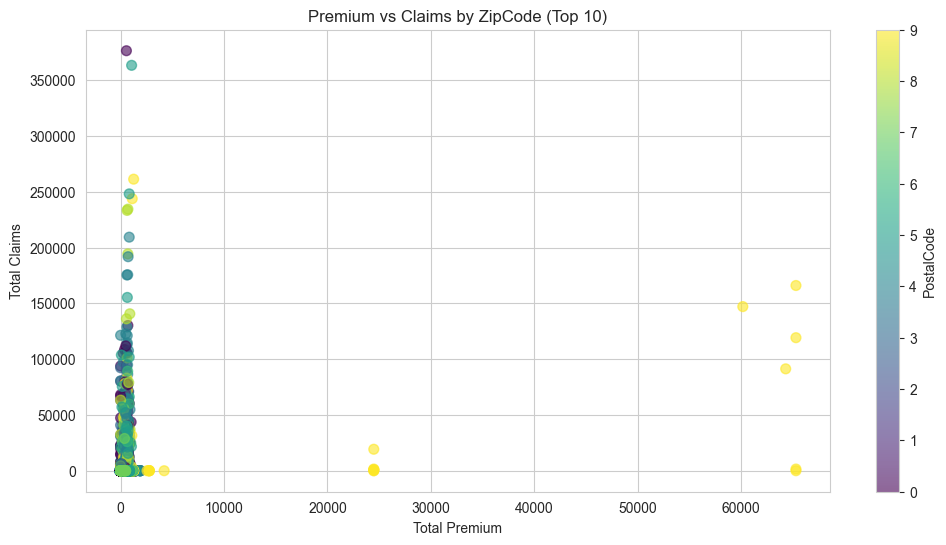

=== Top Correlations with TotalClaims ===
ClaimAmount                 1.000000
TotalClaims                 1.000000
TotalPremium                0.121588
CalculatedPremiumPerTerm    0.079787
RegistrationYear            0.005197
kilowatts                   0.003099
UnderwrittenCoverID         0.003011
PolicyID                    0.002941
NumberOfDoors               0.001700
cubiccapacity               0.001228
Name: TotalClaims, dtype: float64


In [13]:
# Bivariate Analysis - Premium vs Claims by ZipCode (top 10 zip codes)
top_zipcodes = df['PostalCode'].value_counts().head(10).index
df_top_zip = df[df['PostalCode'].isin(top_zipcodes)]

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(df_top_zip['TotalPremium'], df_top_zip['TotalClaims'], 
                     c=df_top_zip['PostalCode'].astype('category').cat.codes, 
                     alpha=0.6, s=50, cmap='viridis')
ax.set_xlabel('Total Premium')
ax.set_ylabel('Total Claims')
ax.set_title('Premium vs Claims by ZipCode (Top 10)')
plt.colorbar(scatter, ax=ax, label='PostalCode')
plt.show()

# Correlation matrix
corr_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation = df[corr_cols].corr()
print("=== Top Correlations with TotalClaims ===")
print(correlation['TotalClaims'].sort_values(ascending=False).head(10))

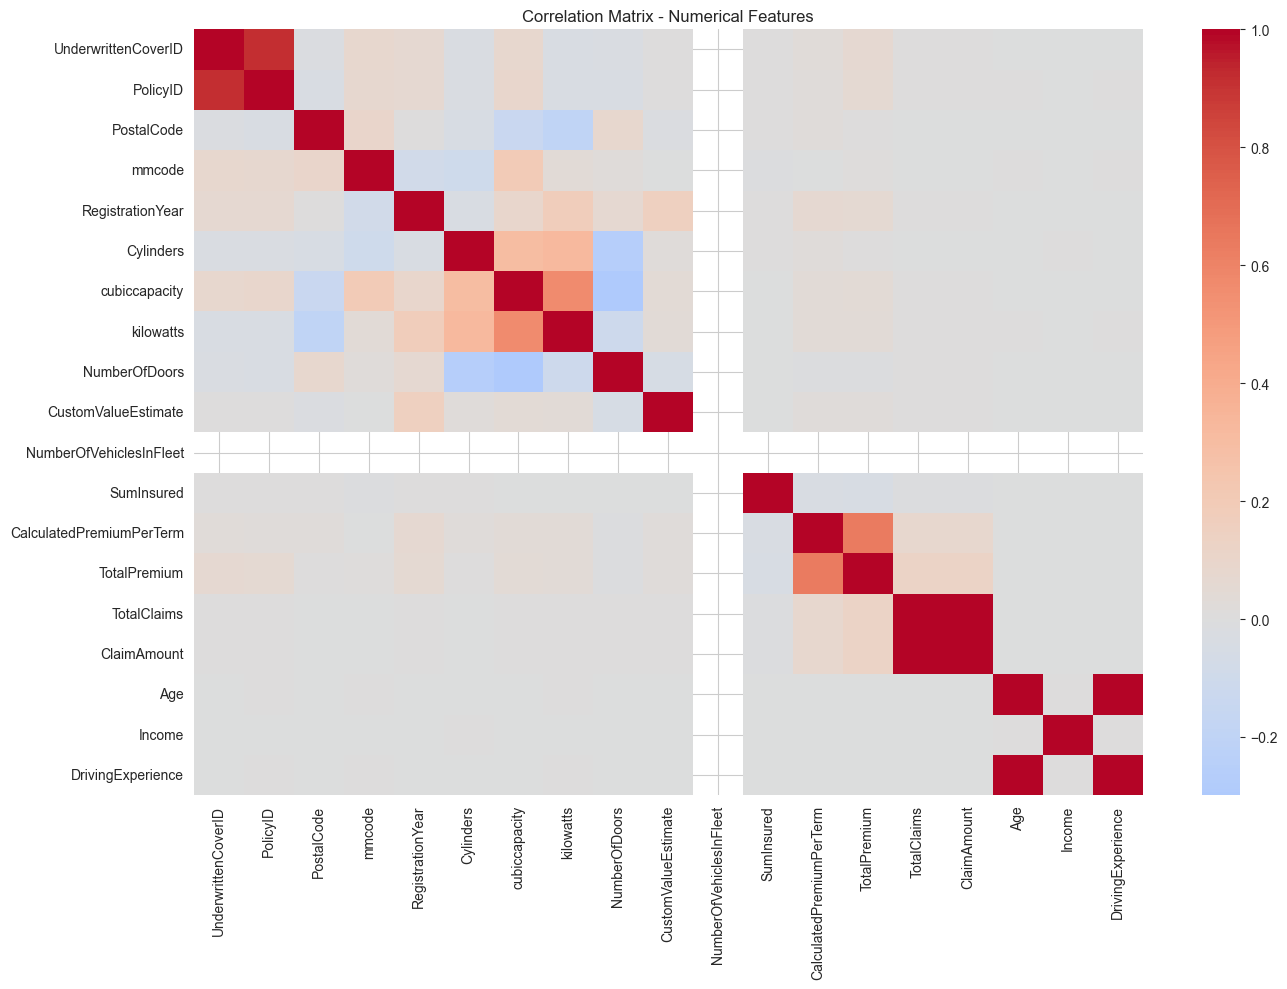

In [14]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(correlation, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

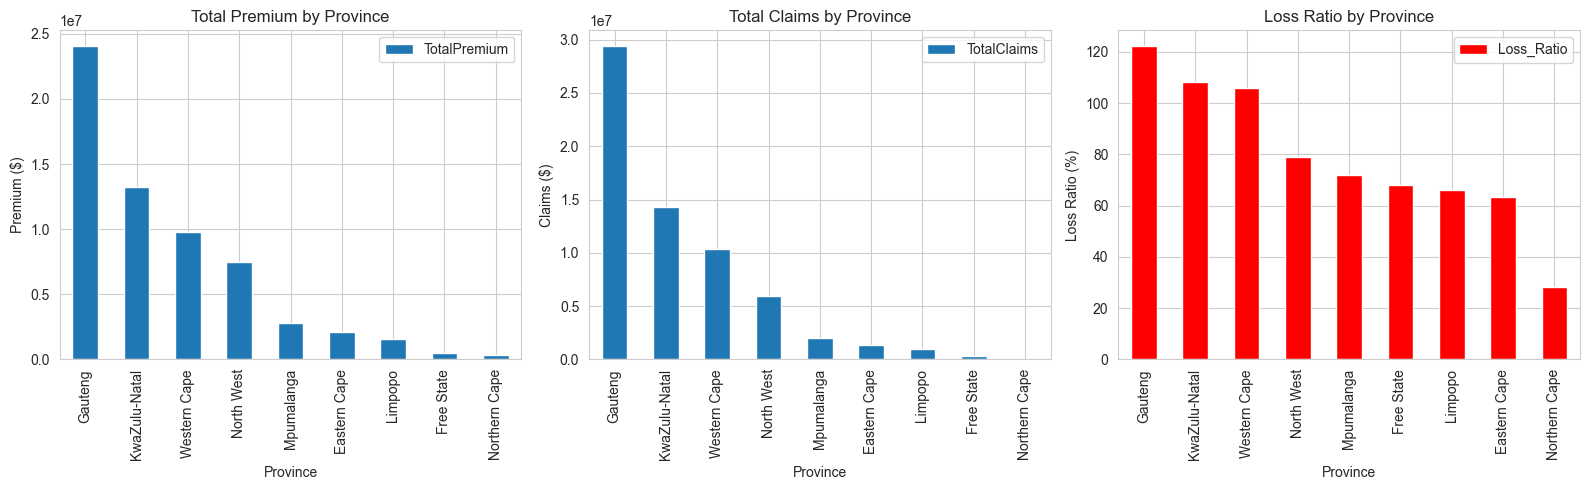

In [15]:
# Geographic Trends - Province Analysis
# Define loss_by_province for analysis
loss_by_province = df.groupby('Province').agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum'
}).reset_index()
loss_by_province['Loss_Ratio'] = (loss_by_province['TotalClaims'] / loss_by_province['TotalPremium'] * 100)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Premium by Province
loss_by_province.sort_values('TotalPremium', ascending=False).plot(x='Province', y='TotalPremium', kind='bar', ax=axes[0])
axes[0].set_title('Total Premium by Province')
axes[0].set_ylabel('Premium ($)')

# Claims by Province
loss_by_province.sort_values('TotalClaims', ascending=False).plot(x='Province', y='TotalClaims', kind='bar', ax=axes[1])
axes[1].set_title('Total Claims by Province')
axes[1].set_ylabel('Claims ($)')

# Loss Ratio by Province
loss_by_province.sort_values('Loss_Ratio', ascending=False).plot(x='Province', y='Loss_Ratio', kind='bar', ax=axes[2], color='red')
axes[2].set_title('Loss Ratio by Province')
axes[2].set_ylabel('Loss Ratio (%)')

plt.tight_layout()
plt.show()

In [16]:
# Vehicle Make/Model Analysis - Highest and Lowest Claim Amounts
print("=== Highest Claim Amounts by Vehicle Make ===")
vehicle_analysis = df[df['Claimed'] == True].groupby('VehicleMake').agg({
    'ClaimAmount': ['mean', 'sum', 'count']
}).reset_index()
vehicle_analysis.columns = ['VehicleMake', 'AvgClaimAmount', 'TotalClaims', 'ClaimCount']
print(vehicle_analysis.sort_values('AvgClaimAmount', ascending=False).head(10))

print("\n=== Lowest Claim Amounts by Vehicle Make ===")
print(vehicle_analysis.sort_values('AvgClaimAmount', ascending=True).head(10))

=== Highest Claim Amounts by Vehicle Make ===
                            VehicleMake  AvgClaimAmount   TotalClaims  \
21                             POLARSUN   125197.843333  1.251978e+05   
10                              HYUNDAI    56663.492325  4.533079e+05   
1                                 B.A.W    47856.245614  2.871375e+05   
9                        GOLDEN JOURNEY    46169.723522  1.246583e+06   
17  MERCEDES-BENZ                          34079.340852  2.385554e+05   
11                                IVECO    31495.539656  7.558930e+05   
0                                  AUDI    30939.506443  1.021004e+06   
26                           VOLKSWAGEN    30150.485741  1.839180e+06   
5                                   CMC    30082.171180  1.323616e+06   
6                                  FIAT    26721.907895  1.068876e+05   

    ClaimCount  
21           1  
10           8  
1            6  
9           27  
17           7  
11          24  
0           33  
26          61

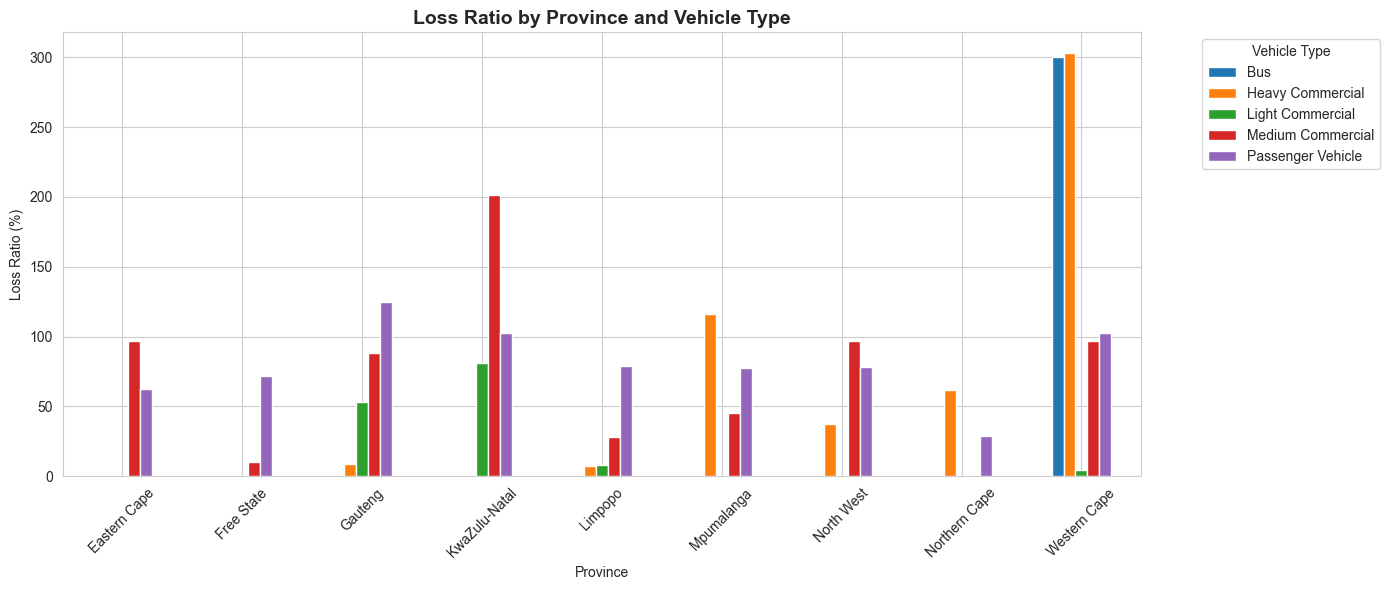

In [17]:
# Creative Plot 1: Loss Ratio by Province and Vehicle Type
fig, ax = plt.subplots(figsize=(14, 6))
province_vehicle = df.groupby(['Province', 'VehicleType']).agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum'
}).reset_index()
province_vehicle['Loss_Ratio'] = (province_vehicle['TotalClaims'] / province_vehicle['TotalPremium'] * 100)
pivot_data = province_vehicle.pivot(index='Province', columns='VehicleType', values='Loss_Ratio')
pivot_data.plot(kind='bar', ax=ax)
ax.set_title('Loss Ratio by Province and Vehicle Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Loss Ratio (%)')
ax.set_xlabel('Province')
plt.xticks(rotation=45)
plt.legend(title='Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

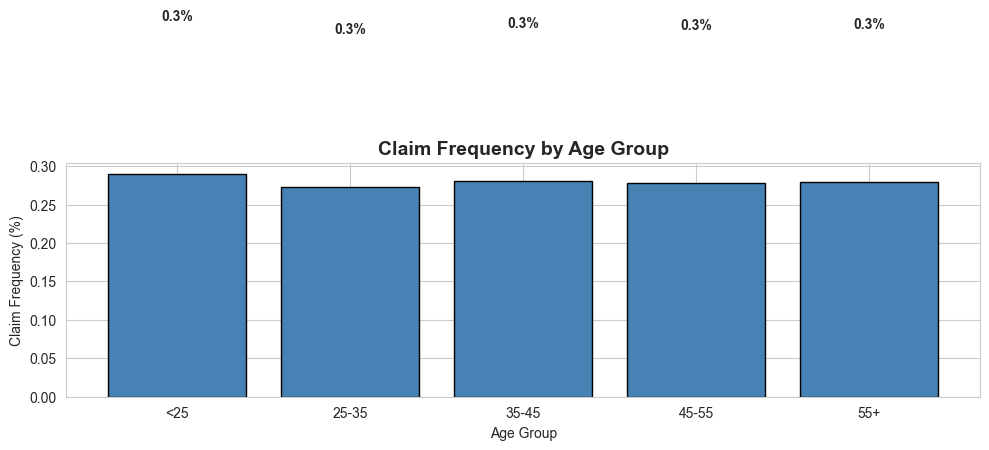

In [18]:
# Creative Plot 2: Claim Frequency Distribution by Age Groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100], labels=['<25', '25-35', '35-45', '45-55', '55+'])
age_claim = df.groupby('AgeGroup')['Claimed'].agg(['sum', 'count', 'mean']).reset_index()
age_claim['Claim_Frequency'] = age_claim['mean'] * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(age_claim['AgeGroup'], age_claim['Claim_Frequency'], color='steelblue', edgecolor='black')
ax.set_title('Claim Frequency by Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Claim Frequency (%)')
ax.set_xlabel('Age Group')
for i, v in enumerate(age_claim['Claim_Frequency']):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

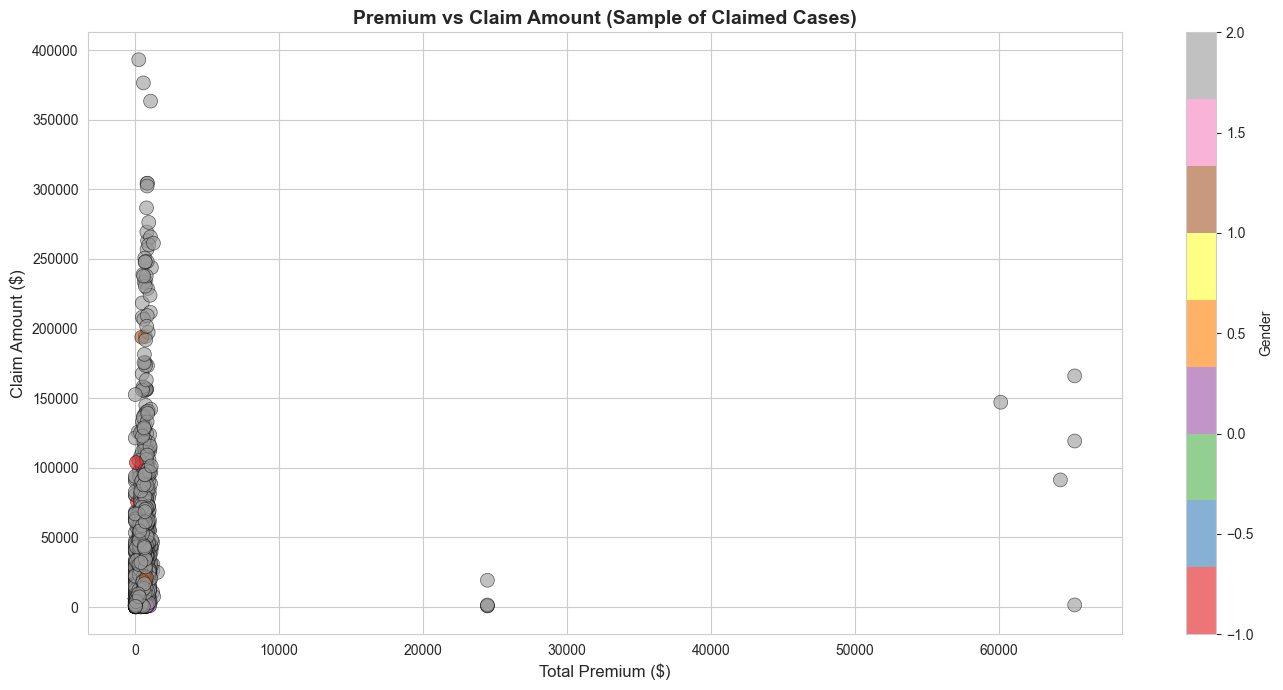

In [19]:
# Creative Plot 3: Premium vs Claim Amount by Gender and Vehicle Type
fig, ax = plt.subplots(figsize=(14, 7))
df_claimed = df[df['Claimed'] == True].sample(n=min(5000, len(df[df['Claimed'] == True])), random_state=42)
scatter = ax.scatter(df_claimed['TotalPremium'], df_claimed['ClaimAmount'], 
                     c=df_claimed['Gender'].astype('category').cat.codes,
                     s=100, alpha=0.6, cmap='Set1', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Total Premium ($)', fontsize=12)
ax.set_ylabel('Claim Amount ($)', fontsize=12)
ax.set_title('Premium vs Claim Amount (Sample of Claimed Cases)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Gender')
plt.tight_layout()
plt.show()

In [20]:
# Summary Statistics and Key Findings
# Define summary metrics
overall_loss_ratio = (df['TotalClaims'].sum() / df['TotalPremium'].sum() * 100)
overall_claim_rate = (df['Claimed'].mean() * 100)
average_claim_cost = df[df['Claimed'] == True]['ClaimAmount'].mean()

print("=== KEY EDA FINDINGS ===")
print(f"\n1. Overall Portfolio Loss Ratio: {overall_loss_ratio:.2f}%")
print(f"2. Overall Claim Frequency: {overall_claim_rate:.2f}%")
print(f"3. Average Claim Amount: ${average_claim_cost:,.2f}")
print(f"\n4. Highest Loss Ratio Province: {loss_by_province.loc[loss_by_province['Loss_Ratio'].idxmax(), 'Province']}")
print(f"5. Highest Loss Ratio Vehicle Type: {loss_by_vehicle.loc[loss_by_vehicle['Loss_Ratio'].idxmax(), 'VehicleType']}")
print(f"\n6. Dataset Size: {df.shape[0]:,} records, {df.shape[1]} columns")

=== KEY EDA FINDINGS ===

1. Overall Portfolio Loss Ratio: 104.77%
2. Overall Claim Frequency: 0.28%
3. Average Claim Amount: $23,273.39

4. Highest Loss Ratio Province: Gauteng
5. Highest Loss Ratio Vehicle Type: Heavy Commercial

6. Dataset Size: 1,000,098 records, 59 columns
